In [ ]:

from google.colab import files
uploaded = files.upload()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


In [ ]:
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/credit_risk_dataset.csv")

In [6]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output.html')

/tmp/ipykernel_347/484759429.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 21.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
df = df.drop_duplicates()

In [8]:
df = df[(df['person_age'] <= 100) &
        ((df['person_emp_length'] <= 60) | df['person_emp_length'].isnull())]

In [9]:
df['Age_to_Credit_History'] = df['person_age'] / df['cb_person_cred_hist_length']

In [10]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder

In [14]:
skewed_num_cols = ['person_age', 'person_income', 'loan_amnt', 'person_emp_length', 'loan_percent_income']
other_num_cols = ['loan_int_rate', 'cb_person_cred_hist_length', 'Age_to_Credit_History']
nominal_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
ordinal_cols = ['loan_grade']

In [17]:
skewed_num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('power_transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

In [18]:
other_num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [19]:
nominal_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

In [20]:
loan_grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[loan_grade_order], handle_unknown='use_encoded_value', unknown_value=-1))
])

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed_num', skewed_num_pipeline, skewed_num_cols),
        ('other_num', other_num_pipeline, other_num_cols),
        ('nominal', nominal_pipeline, nominal_cols),
        ('ordinal', ordinal_pipeline, ordinal_cols)
    ],
    remainder='drop'
)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=3.5))
    ])
}

In [30]:
param_grids = {
    'Logistic Regression': {
        'clf__C': [0.1, 1.0, 10.0]
    },
    'Random Forest': {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [10, 20]
    },
    'XGBoost': {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.01, 0.1],
        'clf__max_depth': [3, 6]
    }
}

In [31]:
from sklearn.model_selection import GridSearchCV

best_models = {}

for name, pipeline in pipelines.items():
    print(f"Training and Tuning {name}...")
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring='recall',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best parameters for {name}: {grid.best_params_}")

Training and Tuning Logistic Regression...
Best parameters for Logistic Regression: {'clf__C': 0.1}
Training and Tuning Random Forest...
Best parameters for Random Forest: {'clf__max_depth': 10, 'clf__n_estimators': 100}
Training and Tuning XGBoost...
Best parameters for XGBoost: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}


In [32]:
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Recall (Default)': recall_score(y_test, y_pred),
        'Precision (Default)': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC Score': roc_auc_score(y_test, y_proba)
    })

comparison_df = pd.DataFrame(results)
display(comparison_df.sort_values(by='Recall (Default)', ascending=False))

,Model,Recall (Default),Precision (Default),F1-Score,ROC-AUC Score
2,XGBoost,0.803949,0.761015,0.781893,0.942444
0,Logistic Regression,0.790550,0.491236,0.605946,0.854260
1,Random Forest,0.758815,0.822630,0.789435,0.931576


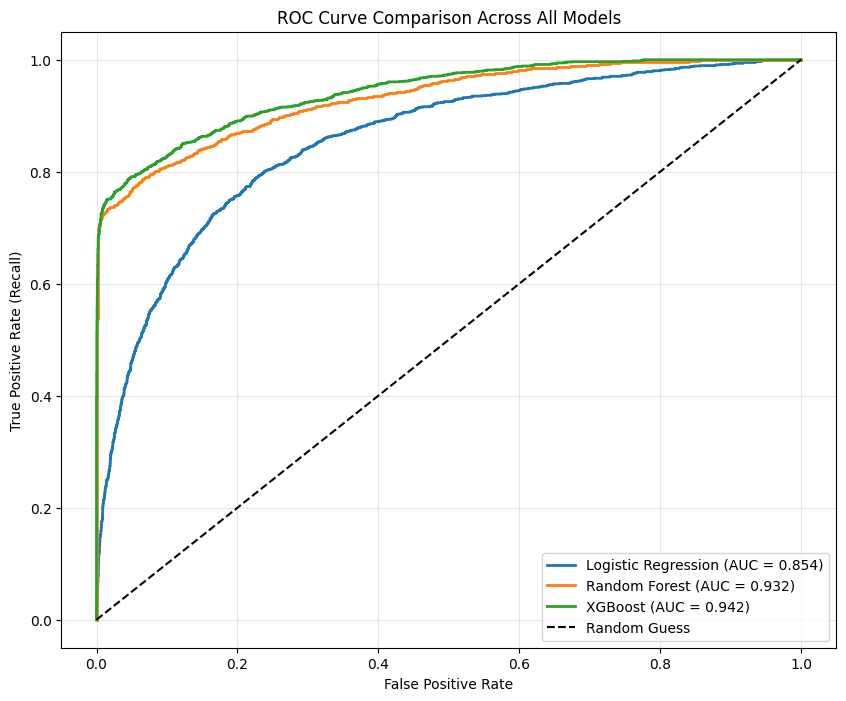

In [33]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    auc_score = comparison_df.loc[comparison_df['Model'] == name, 'ROC-AUC Score'].values[0]
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Guess')
plt.title('ROC Curve Comparison Across All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

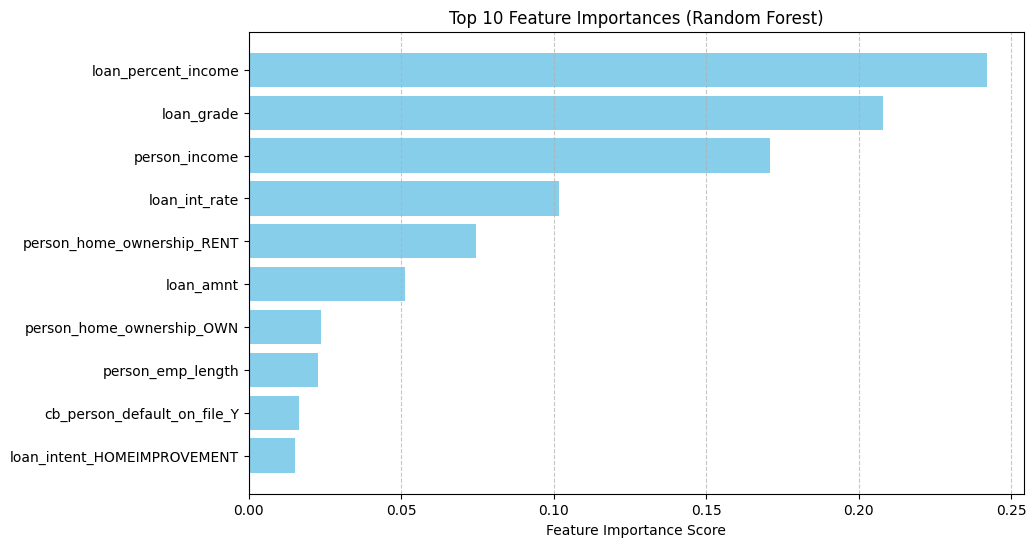

In [34]:
import matplotlib.pyplot as plt

best_rf = best_models['Random Forest']

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['clf'].feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_imp_df['Feature'] = feature_imp_df['Feature'].str.split('__').str[-1]

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][:10][::-1], feature_imp_df['Importance'][:10][::-1], color='skyblue')
plt.xlabel('Feature Importance Score')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

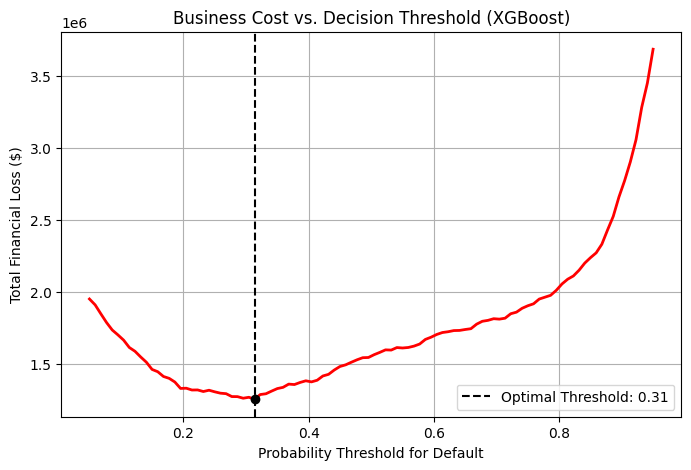

Optimal Probability Threshold: 0.31
Minimum Total Cost: $1,254,000.00


In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix

best_xgb = best_models['XGBoost']
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

COST_FN = 5000
COST_FP = 500

thresholds = np.linspace(0.05, 0.95, 100)
total_costs = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_best >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)

    tn, fp, fn, tp = cm.ravel()
    cost = (fn * COST_FN) + (fp * COST_FP)
    total_costs.append(cost)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, total_costs, color='red', lw=2)

min_cost_idx = np.argmin(total_costs)
optimal_thresh = thresholds[min_cost_idx]
min_cost = total_costs[min_cost_idx]

plt.axvline(optimal_thresh, color='black', linestyle='--', label=f'Optimal Threshold: {optimal_thresh:.2f}')
plt.scatter(optimal_thresh, min_cost, color='black', zorder=5)

plt.title('Business Cost vs. Decision Threshold (XGBoost)')
plt.xlabel('Probability Threshold for Default')
plt.ylabel('Total Financial Loss ($)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal Probability Threshold: {optimal_thresh:.2f}")
print(f"Minimum Total Cost: ${min_cost:,.2f}")